# eTraGo: Minimal Example

The following notebook shows you how you can run the selected, basic functions of eTraGo in a minimal system.
First, the execution is shown step by step, including information on different functionalities.
Afterwards, information on more automated eTraGo runs is provided.

More information on the described functions, as well as a description of all options, is provided in the __[eTraGo Documentation on read the docs](http://etrago.readthedocs.io/)__

## Import required general and eTraGo specific python packages

In [38]:
import warnings
warnings.filterwarnings('ignore')

from etrago import Etrago
import pypsa

## Initialize object and set parameters

In [39]:
etrago = Etrago(args={}, json_path="args_minimal_example.json")

## View and adjust parameters

All parameters of an eTraGo calculation are stored in etrago.args. 
They can be defined via a json-file or as a dictionary. Documentation on all parameters is provided in the read the docs. 
This example shows how to show and adjust selected key settings: 

In [40]:
# Scenario name
etrago.args["scn_name"]

'eGon2035'

### Snapshots considered in calculation
For a small example, a limited number of snapshots is selected. For larger, annual calculations eTraGo needs more RAM then a normal laptop provides.
The snapshots are defined as the nth number in a year, so it can be between 1 and 8760.
In this example, the first day of the year is selected:

In [41]:
print(etrago.args["start_snapshot"])
print(etrago.args["end_snapshot"])

1
24


In [42]:
etrago.args

{'db': 'oep',
 'gridversion': None,
 'method': {'type': 'lopf',
  'n_iter': 1,
  'formulation': 'pyomo',
  'market_optimization': {'active': False,
   'market_zones': 'status_quo',
   'rolling_horizon': {'planning_horizon': 168, 'overlap': 120},
   'redispatch': True},
  'distribution_grids': False},
 'pf_post_lopf': {'active': False,
  'add_foreign_lopf': True,
  'q_allocation': 'p_nom'},
 'start_snapshot': 1,
 'end_snapshot': 24,
 'solver': 'glpk',
 'solver_options': {},
 'model_formulation': 'kirchhoff',
 'scn_name': 'eGon2035',
 'scn_extension': None,
 'lpfile': False,
 'csv_export': False,
 'extendable': {'extendable_components': ['as_in_db', 'foreign_storage'],
  'upper_bounds_grid': {'grid_max_D': None,
   'grid_max_abs_D': {'380': {'i': 1020, 'wires': 4, 'circuits': 4},
    '220': {'i': 1020, 'wires': 4, 'circuits': 4},
    '110': {'i': 1020, 'wires': 4, 'circuits': 2},
    'dc': 0},
   'grid_max_foreign': 4,
   'grid_max_abs_foreign': None}},
 'generator_noise': 789456,
 'extr

## Import data model from the database

In [43]:
etrago.build_network_from_db()
etrago.adjust_network()

INFO:etrago.tools.io:Importing Buses from database
INFO:etrago.tools.io:Importing Lines from database
INFO:etrago.tools.io:Importing Transformers from database
INFO:etrago.tools.io:Importing Links from database
INFO:etrago.tools.io:Importing Loads from database
INFO:etrago.tools.io:Importing Generators from database
INFO:etrago.tools.io:Importing Storages from database
INFO:etrago.tools.io:Importing Stores from database
INFO:etrago.network:Imported network from db
INFO:etrago.tools.utilities:
            There are 7 lines without a resistance (r) in the data model.
            The resistance of these lines will be automatically set to 0.0001.
            
INFO:etrago.tools.utilities:There are 518 trafos without a resistance (r) in the data model.
            The resistance of these trafos will be automatically set to 0.0001.
            


## Complexity Reduction
The data model is characterized by a high spatial (about 8,000 electrical and 600 gas nodes) and temporal resolution (8,760 timesteps). To reduce the complexity of the resulting optimization problem, several methods can be applied.
In this example, we focus on the spatial complexity reduction.

This is how the network looks like in the original resolution:

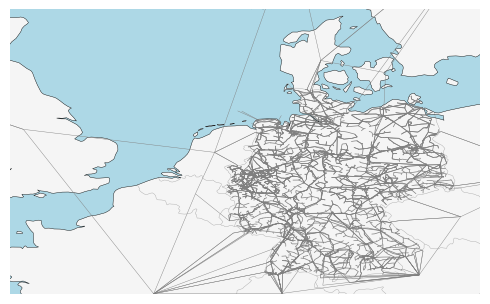

In [44]:
etrago.plot_grid("grey")

In the following, spatial complexity methods are applied. In this minimal example, the electrical network is clustered to 30 nodes.

_Please note that this step can take a few minutes._

In [45]:
# spatial clustering
#etrago.spatial_clustering()
#etrago.spatial_clustering_gas()
#etrago.network.export_to_csv_folder("clustered_grid")

Da das clustering einige Minuten Zeit braucht, überspringen wir die Berechnungszeit und laden das Ergebnis:

In [46]:
import pypsa
etrago.network = pypsa.Network("clustered_grid")

INFO:pypsa.io:Imported network clustered_grid has buses, generators, lines, links, loads, storage_units, stores


Afterwards, the electrical grid looks like this:

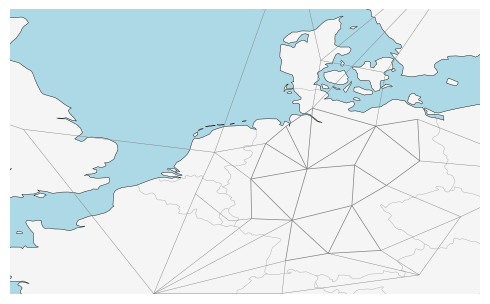

In [47]:
etrago.plot_grid("grey")

## Optimization

eTraGo includes different methods to optimize the German energy system, including the eHV/HV grid.
In this example, an integrated LOPF is selected. This optimizes the dispatch of generation and flexibility options as well as grid and storage expansion in one integrated optimization step.

_Please note that the solver glpk needs to be installed._

In [48]:
etrago.optimize()

INFO:pypsa.opf:Performed preliminary steps
INFO:pypsa.opf:Building pyomo model using `kirchhoff` formulation
INFO:pypsa.opf:Solving model using glpk
INFO:pypsa.opf:Optimization successful
INFO:etrago.execute:Time for LOPF [min]: 0.44


# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 484264625.430364
  Upper bound: 484264625.430364
  Number of objectives: 1
  Number of constraints: 34729
  Number of variables: 26024
  Number of nonzeros: 84521
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 19.725472688674927
# ----------------------------------------------------------
#   Solution Information
# ----

## Result analysis

eTraGo includes different functions to analyze the results.

_Please note that the results of the minimal example are not representative, they are just shown to explain the general usage._

In the following, a map of grid and storage expansion is visualized:

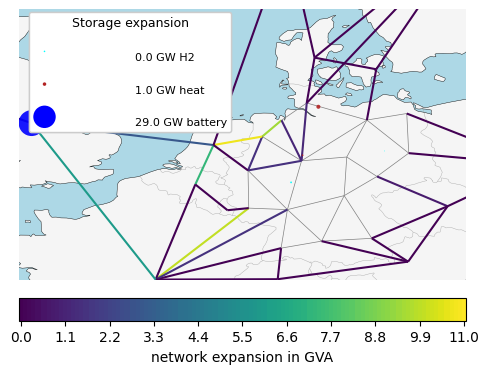

In [49]:
etrago.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 10,
                            "heat": 10,
                            "battery": 10})

## Szenariovariation: Begrenzung Netzausbau

In [65]:
etrago.args['extra_functionality']={"max_line_ext":1.05}

In [66]:
etrago.optimize()

INFO:pypsa.opf:Performed preliminary steps
INFO:pypsa.opf:Building pyomo model using `kirchhoff` formulation
INFO:etrago.tools.constraints:Added extra_functionality max_line_ext
INFO:pypsa.opf:Solving model using glpk
INFO:pypsa.opf:Optimization successful
INFO:etrago.execute:Time for LOPF [min]: 0.46


# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 484553282.633222
  Upper bound: 484553282.633222
  Number of objectives: 1
  Number of constraints: 34730
  Number of variables: 26024
  Number of nonzeros: 84587
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  Termination condition: optimal
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: 0
      Number of created subproblems: 0
  Error rc: 0
  Time: 21.775206089019775
# ----------------------------------------------------------
#   Solution Information
# ----

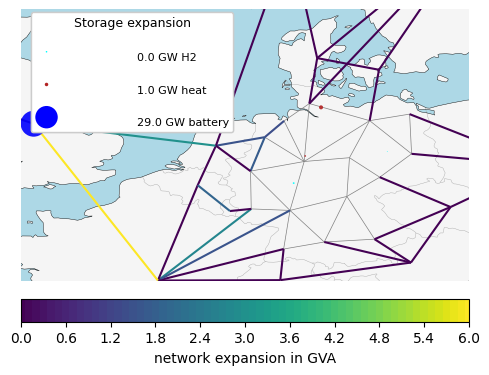

In [67]:
etrago.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 10,
                            "heat": 10,
                            "battery": 10})

# Analyzing results

Loading predefined results

In [68]:
etrago_larger_model = Etrago(csv_folder_name="/home/clara/Documents/regon/bottom_up/first_etrago_results/results_dg_1702")

INFO:pypsa.io:Imported network results_dg_1702 has buses, carriers, generators, lines, links, loads, storage_units, stores
                            Could not import a market_model but the selected
                            method in the args indicated that it should be
                            there. This happens when the exported network was
                            not solved yet.Run 'etrago.optimize()' to build
                            and solve the market model.
                            
INFO:pypsa.io:Imported network clustering has buses, lines, links


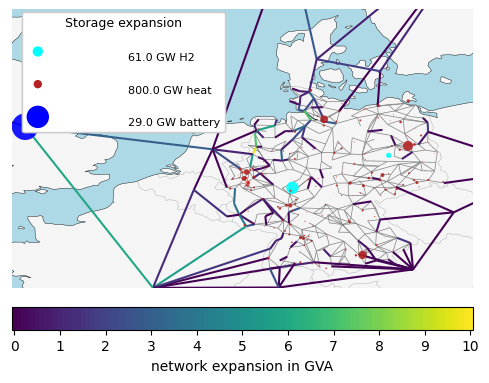

In [73]:
etrago_larger_model.plot_grid(
    line_colors="expansion_abs",
    bus_colors = "storage_expansion", bus_sizes= 0.000001,
    scaling_store_expansion={"H2": 1,
                            "heat": 0.05,
                            "battery": 10})

eTraGo also includes functions to calculate general results as tables, such as system costs and total grid expansion:

In [74]:
etrago_larger_model.calc_results()
etrago_larger_model.results

,unit,value
annual system costs,EUR/a,138545667095.722382
annual investment costs,EUR/a,3169773298.377575
annual marginal costs,EUR/a,135375893797.344803
annual electrical grid investment costs,EUR/a,1243848405.093954
annual ac grid investment costs,EUR/a,213795061.748313
annual dc grid investment costs,EUR/a,1030053343.345642
annual links investment costs,EUR/a,870903094.501502
annual storage+store investment costs,EUR/a,1055021798.782119
annual electrical storage investment costs,EUR/a,320590496.732282
annual store investment costs,EUR/a,734431302.049837
